In [1]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df_US_DA = df[
    (df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')
].copy()

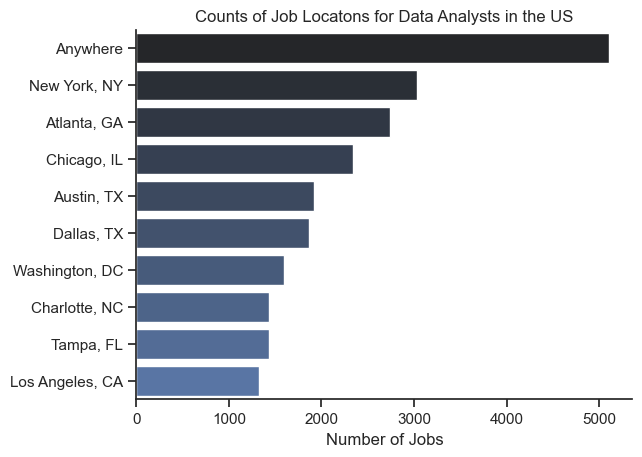

In [18]:
df_plot = df_US_DA['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot, 
    x='count', 
    y=df_plot.index,
    palette='dark:b'
)
sns.despine()

plt.title('Counts of Job Locatons for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

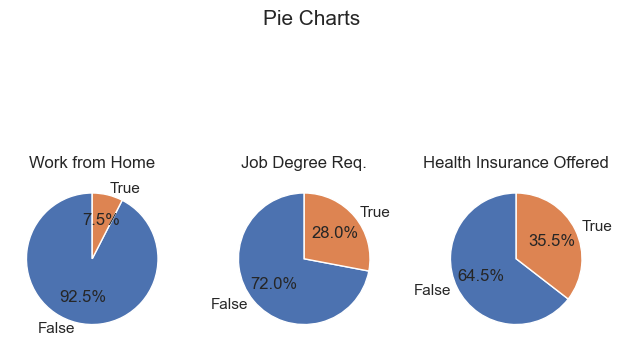

In [17]:
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.', 
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (col, title) in enumerate(dict_column.items()):
    data = df_US_DA[col].value_counts()
    ax[i].pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

fig.suptitle('Pie Charts', fontsize=15)
fig.tight_layout()

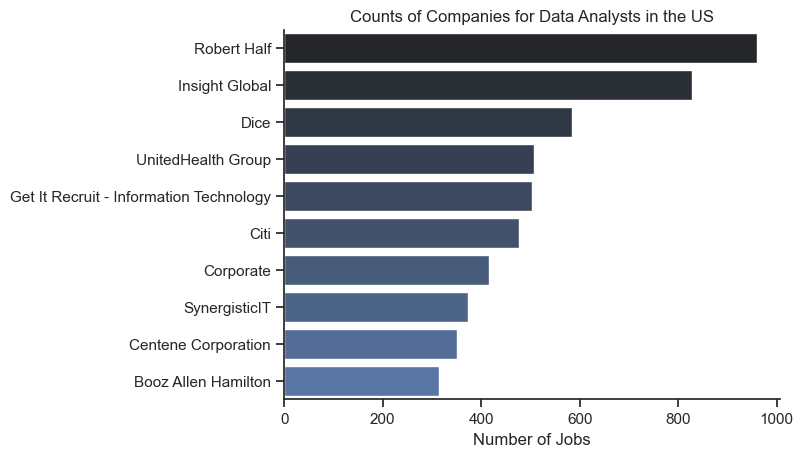

In [ ]:
df_plot = df_US_DA['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot, 
    x='count', 
    y=df_plot.index,
    palette='dark:b'
)
sns.despine()

plt.title('Counts of Companies for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

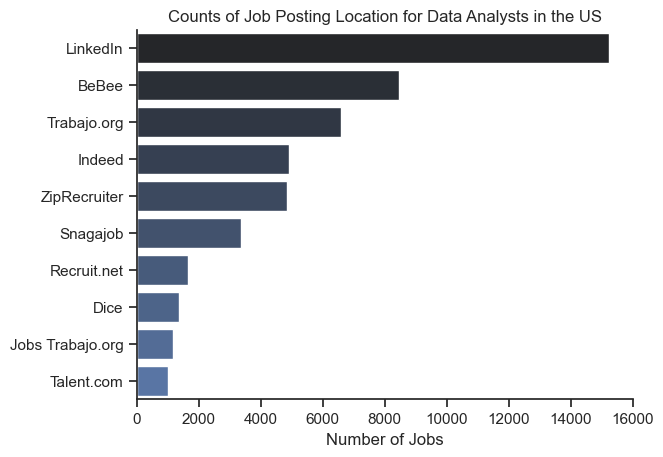

In [25]:
df_plot = df_US_DA['job_via'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot, 
    x='count', 
    y=df_plot.index.str.removeprefix('via '),
    palette='dark:b'
)
sns.despine()

plt.title('Counts of Job Posting Location for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()